# A/B-тест на обновление списка рекламы от партнеров

**Импорт библиотек**

In [142]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from tqdm import tqdm
from scipy import stats

In [143]:
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

**Загрузка данных**

In [144]:
# Исторические данные, которые содержат поведение пользователей ДО эксперимента.
# Используются для: EDA, предобработки, расчета sample size, симуляции A/A-теста.
df1 = pd.read_csv('../data/user_activity_data.csv')

# Данные эксперимента, которые содержат реальные группы пользователей и их метрики.
# Используются для: проверки гипотезы, расчета p-value, формирования рекомендаций.
df2 = pd.read_csv('../data/experiment_data.csv')

In [145]:
df1.head(1)

,date,user_id,device,pages_viewed,paid_clicks,organic_clicks,revenue
0,2026-01-01,1,mobile,18,6,0,11.3


In [146]:
df2.head(1)

,user_id,pages_viewed,paid_clicks,organic_clicks,revenue,device,ctr_paid,ctr_organic,group
0,1,61,15,10,35.06,mobile,0.245902,0.163934,control


**Предобработка данных**

In [147]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89353 entries, 0 to 89352
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            89353 non-null  object 
 1   user_id         89353 non-null  int64  
 2   device          89353 non-null  object 
 3   pages_viewed    89353 non-null  int64  
 4   paid_clicks     89353 non-null  int64  
 5   organic_clicks  89353 non-null  int64  
 6   revenue         89353 non-null  float64
dtypes: float64(1), int64(4), object(2)
memory usage: 4.8+ MB


In [148]:
# Преобразование строки в дату
df1['date'] = pd.to_datetime(df1['date'])

In [149]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89353 entries, 0 to 89352
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            89353 non-null  datetime64[ns]
 1   user_id         89353 non-null  int64         
 2   device          89353 non-null  object        
 3   pages_viewed    89353 non-null  int64         
 4   paid_clicks     89353 non-null  int64         
 5   organic_clicks  89353 non-null  int64         
 6   revenue         89353 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(4), object(1)
memory usage: 4.8+ MB


Все колонки имеют подходящий тип. В данных нет пропусков.

*Обработка выбросов*

In [150]:
# функция, которая удаляет значения, выходящие за пределы интерквартильного диапазона.
def remove_outliers_iqr(data, column_name):
  Q1 = np.percentile(data[column_name], 25)
  Q3 = np.percentile(data[column_name], 75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  cleaned_data = data[(data[column_name] > lower_bound) & (data[column_name] < upper_bound)]
  return cleaned_data

# Удаление выбросов по полю paid_clicks (целевая метрика гипотезы)
cleaned_df1 = remove_outliers_iqr(df1, 'paid_clicks')

percent_removed = ((len(df1) - len(cleaned_df1)) / len(df1)) * 100
print("Процент удаленных данных: {:.2f}%".format(percent_removed))

Процент удаленных данных: 1.98%


После удаления выбросов по полю paid_clicks мы наблюдаем следующие изменения в распределении метрик:

In [151]:
print(f"paid_clicks (среднее значение): {round((cleaned_df1['paid_clicks'].mean() - df1['paid_clicks'].mean()) / df1['paid_clicks'].mean() * 100, 2)}%")

paid_clicks (среднее значение): -6.45%


In [152]:
print(f"paid_clicks (стандартное отклонение): {round(cleaned_df1['paid_clicks'].std() - df1['paid_clicks'].std(), 2)}")

paid_clicks (стандартное отклонение): -0.45


**Изучение датасета**

In [153]:
print(f"Кол-во уникальных пользователей: {cleaned_df1['user_id'].nunique()}")

Кол-во уникальных пользователей: 3000


In [154]:
print(f"Период данных: {min(cleaned_df1['date'])} - {max(cleaned_df1['date'])}")

Период данных: 2026-01-01 00:00:00 - 2026-02-25 00:00:00


*Распределение метрик*

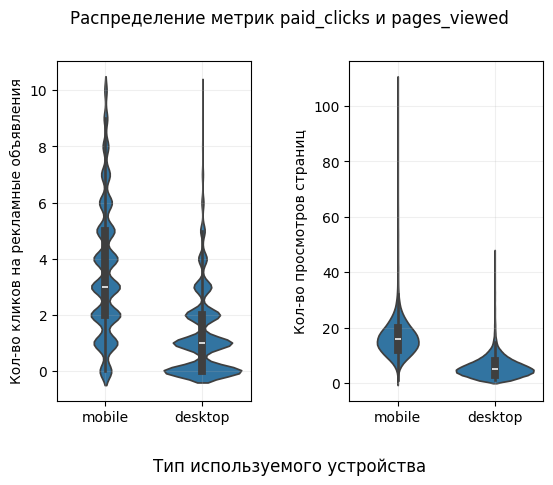

In [155]:
fig, ax = plt.subplots(1, 2)
fig.tight_layout(pad=4.0)

sns.violinplot(data=cleaned_df1, y='paid_clicks', x='device', ax=ax[0])
ax[0].grid(alpha=0.2)

ax[0].set_xlabel('')
ax[0].set_ylabel('Кол-во кликов на рекламные объявления')

sns.violinplot(data=cleaned_df1, y='pages_viewed', x='device', ax=ax[1])
ax[1].grid(alpha=0.2)

ax[1].set_ylabel('Кол-во просмотров страниц')
ax[1].set_xlabel('')

fig.supxlabel('Тип используемого устройства')
fig.suptitle('Распределение метрик paid_clicks и pages_viewed');


In [156]:
cleaned_df1['device'].value_counts()

,count
device,
mobile,69196
desktop,18390


Метрики различаются в зависимости от типа устройства.
- Сравнение по кликам (Левый график): мобильные пользователи склонны кликать чаще (и больше по количеству), чем пользователи с десктопов.
- Сравнение по просмотрам страниц (Правый график): Мобильные пользователи просматривают больше страниц, чем пользователи с десктопов.
<br>Это объясняется тем, что смартфоны чаще всего используются в моменты «убивания времени»: в транспорте, в очередях, лежа на диване. Компьютер чаще используется для целенаправленных задач (работа, поиск конкретной информации).

*Добавление 2 метрик конверсии: из просмотров в платные клики и органические*

In [157]:
cleaned_df1['ctr_paid'] = cleaned_df1['paid_clicks'] / cleaned_df1['pages_viewed']
cleaned_df1['ctr_organic'] = cleaned_df1['organic_clicks'] / cleaned_df1['pages_viewed']

In [158]:
cleaned_df1.head(1)

,date,user_id,device,pages_viewed,paid_clicks,organic_clicks,revenue,ctr_paid,ctr_organic
0,2026-01-01,1,mobile,18,6,0,11.3,0.333333,0.0


*Закономерности в конверсиях*

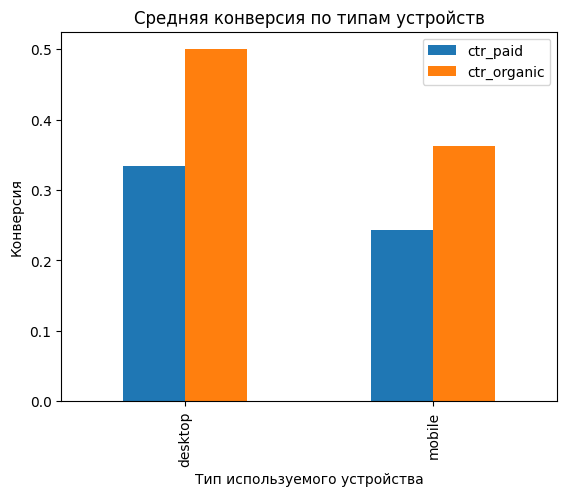

In [159]:
device_ctr = cleaned_df1.groupby('device')[['ctr_paid', 'ctr_organic']].mean().reset_index()

device_ctr.plot(kind='bar', x='device')

plt.xlabel('Тип используемого устройства')
plt.ylabel('Конверсия')
plt.title('Средняя конверсия по типам устройств');

Конверсия в "органические" клики на обоих устройствах выше, чем в "платные", что говорит о приоритете пользователей к чтению контента издателя над рекламой. При этом десктопные пользователи демонстрируют более высокий CTR (как по "платным", так и по "органическим" элементам) по сравнению с мобильными.

*Корреляция между метриками*

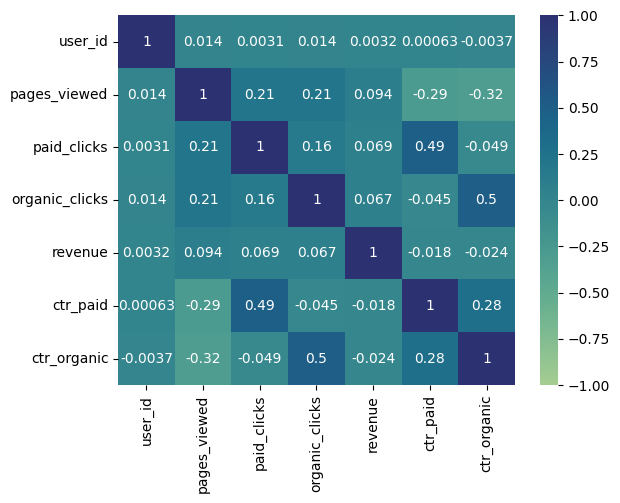

In [160]:
sns.heatmap(cleaned_df1.corr(numeric_only=True), annot=True, cbar=True, cmap='crest', vmin=-1, vmax=1);

**Дизайн теста**

Бизнес контекст:
<br>Платформа Marketpele Feed помогает издательствам зарабатывать на рекламе. Список объявлений Marketpele содержит "органические" и "платные" элементы. Платные элементы - это рекламные объявления, при нажатии на них пользователи переходят на страницу рекламодателя и приносят доход Marketpele. Органические элементы - это контент издателя, при нажатии на них пользователи переходят на другую статью от того же издателя.
<br>Бизнес импакт:
<br>Увеличение прибыли

Продуктовая гипотеза: <br>
Размещение 4 платных элементов над 1 органическим увеличит Paid CTR на X%, так как пользователи кликают первое, что видят, не пролистывая.

H0: Paid CTR в группе Б равен Paid CTR в группе А. <br>
H1: Paid CTR в группе Б не равен Paid CTR в группе А.

Метрики: pages_viewed, paid_clicks

Уровень значимости: 5%
<br>Мощность: 80%

In [161]:
# Среднее кол-во пользователей в день
daily_traffic_df = cleaned_df1.groupby(['date'])['user_id'].agg('nunique').reset_index()
daily_traffic_mean = daily_traffic_df['user_id'].mean()
daily_traffic_mean

np.float64(1564.0357142857142)

In [162]:
# Текущий CTR
p1 = cleaned_df1['ctr_paid'].mean()
p1

np.float64(0.26216502427900407)

In [163]:
alpha = 0.05
power = 0.80

*MDE для нескольких вариантов длительности теста (2, 3, 4 недели)*

In [164]:
def mde_relative(daily_traffic_mean, cnt_weeks, alpha, power):
  total_users = daily_traffic_mean * cnt_weeks *7
  sample_size_group = total_users / 2
  effect_size = NormalIndPower().solve_power(
          nobs1=sample_size_group,
          alpha=alpha,
          power=power,
          alternative='two-sided'
      )
  mde_absolute = effect_size * np.sqrt(p1 * (1 - p1))
  mde_relative = (mde_absolute / p1) * 100
  return mde_relative

# 2 недели
mde_2_weeks = mde_relative(daily_traffic_mean, 2, alpha, power)
print(f"MDE для длительности теста 2 недели: {mde_2_weeks}")

# 3 недели
mde_3_weeks = mde_relative(daily_traffic_mean, 3, alpha, power)
print(f"MDE для длительности теста 3 недели: {mde_3_weeks}")

# 4 недели
mde_4_weeks = mde_relative(daily_traffic_mean, 4, alpha, power)
print(f"MDE для длительности теста 4 недели: {mde_4_weeks}")

MDE для длительности теста 2 недели: 6.35240436103041
MDE для длительности теста 3 недели: 5.186728001103485
MDE для длительности теста 4 недели: 4.491807943980776


*Убедимся в том, что дизайн корректный*

In [165]:
# Функция для построения распределения p_value
def draw_cdf_plot(p_values, alpha, label='FPR'):
    sorted_p = np.sort(p_values)
    cdf = np.arange(1, len(sorted_p) + 1) / len(sorted_p)

    plt.figure(figsize=(7, 7))
    plt.plot(sorted_p, cdf, 'b-', linewidth=2, label='Наблюдаемое')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=2, label='Идеальное (равномерное)')
    plt.xlabel('p-value', fontsize=12)
    plt.ylabel('F(p-value)', fontsize=12)
    plt.title('Кумулятивная функция распределения', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.axvline(x=alpha,
           color='blue',
           linestyle='--',
           alpha=0.7,
           linewidth=2)

    # Вычисляем FPR (False Positive Rate)
    fpr_05 = np.mean(np.array(sorted_p) <= alpha)

    plt.tight_layout()
    plt.show()

    print(f'{label} = {fpr_05}')

Длительность 2 недели

Проведём АА-тест (FPR по ctr_paid должен быть в районе выбранного уровня значимости)

In [166]:
# Проводим 1000 A/A-тестов для проверки распределения p-value
n_simulations = 1000
p_values = []
effect = 1

for i in tqdm(range(n_simulations)):
    # Случайное разделение
    temp_data = cleaned_df1.sample(n=int(daily_traffic_mean * 14), random_state=None)
    temp_data['group'] = np.random.choice(['A', 'B'], size=len(temp_data), p=[0.5, 0.5])

    group_a_temp = temp_data.copy()[temp_data['group'] == 'A']
    group_b_temp = temp_data.copy()[temp_data['group'] == 'B']

    group_b_temp['ctr_paid_effected'] = group_b_temp['ctr_paid'] * effect

    # Тест
    t_stat_temp, p_rev_temp = stats.ttest_ind(
        group_a_temp['ctr_paid'],
        group_b_temp['ctr_paid_effected']
    )
    p_values.append(p_rev_temp)

100%|██████████| 1000/1000 [00:19<00:00, 50.68it/s]


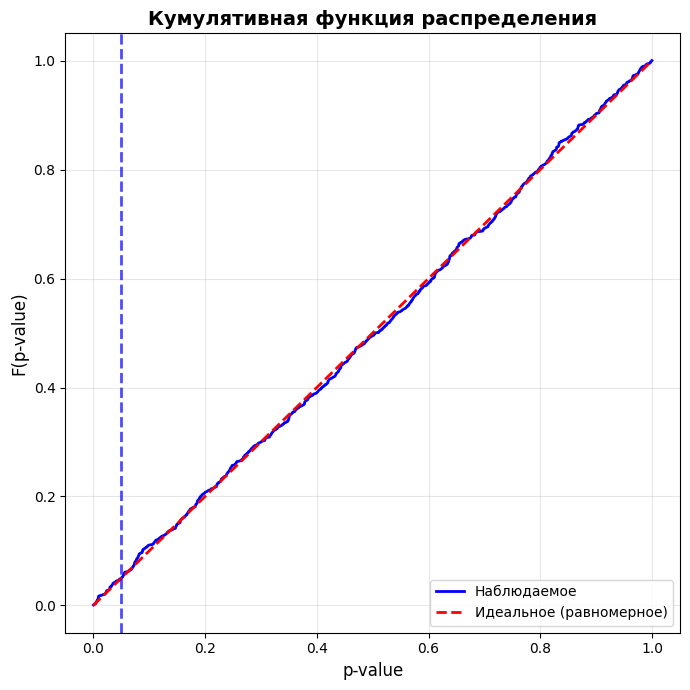

FPR = 0.049


In [167]:
draw_cdf_plot(p_values, 0.05, label='FPR')

Проведём симуляцию АБ-теста для оценки мощности

In [168]:
# Проводим 1000 AБ-тестов для проверки распределения p-value
n_simulations = 1000
p_values = []
effect = 1 + mde_2_weeks/100

for i in tqdm(range(n_simulations)):
    # Случайное разделение
    temp_data = cleaned_df1.sample(n=int(daily_traffic_mean * 14), random_state=None)
    temp_data['group'] = np.random.choice(['A', 'B'], size=len(temp_data), p=[0.5, 0.5])

    group_a_temp = temp_data.copy()[temp_data['group'] == 'A']
    group_b_temp = temp_data.copy()[temp_data['group'] == 'B']

    group_b_temp['ctr_paid_effected'] = group_b_temp['ctr_paid'] * effect

    # Тест
    t_stat_temp, p_rev_temp = stats.ttest_ind(
        group_a_temp['ctr_paid'],
        group_b_temp['ctr_paid_effected']
    )
    p_values.append(p_rev_temp)

100%|██████████| 1000/1000 [00:20<00:00, 48.23it/s]


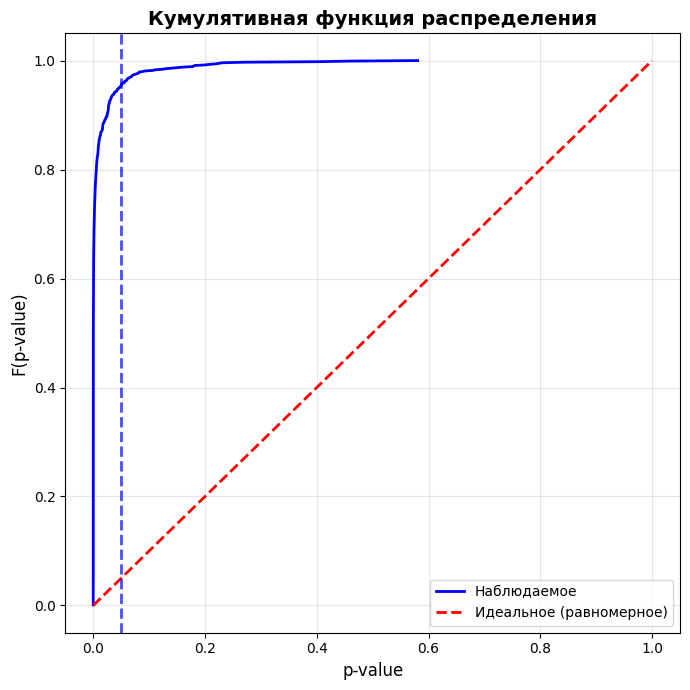

Power = 0.955


In [169]:
draw_cdf_plot(p_values, 0.05, label='Power')

Выбираем дизайн на 2 недели, так как он обеспечивает достаточную мощность (>90%) при минимальной длительности эксперимента, что позволяет быстрее принять бизнес-решение.

*Итоговый дизайн*

Длительность: 14 дней (2 недели)
<br>Доля трафика: 100% (все пользователи, приходящие на платформу в период теста, участвуют в эксперименте)
<br>Метрики: Paid CTR, paid clicks, количество просмотров за сессию
<br>MDE: 6.4%
<br>Способ обработки выбросов: удаление выбросов по полю paid_clicks

<br>Гипотеза: размещение 4 платных элементов над 1 органическим увеличит Paid CTR на 6.4%, так как пользователи кликают первое, что видят, не пролистывая.

**Анализ результатов теста**

In [170]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1983 entries, 0 to 1982
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         1983 non-null   int64  
 1   pages_viewed    1983 non-null   int64  
 2   paid_clicks     1983 non-null   int64  
 3   organic_clicks  1983 non-null   int64  
 4   revenue         1983 non-null   float64
 5   device          1983 non-null   object 
 6   ctr_paid        1983 non-null   float64
 7   ctr_organic     1983 non-null   float64
 8   group           1983 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 139.6+ KB


*Анализ распределения ctr_paid в группах*

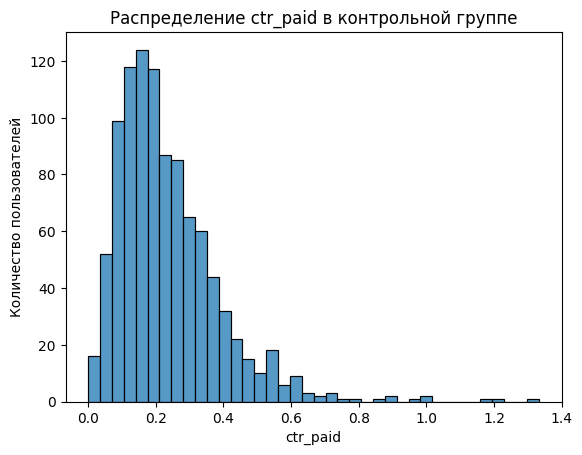

In [171]:
sns.histplot(df2[df2['group'] == 'control']['ctr_paid'])

plt.title('Распределение ctr_paid в контрольной группе')
plt.ylabel('Количество пользователей');

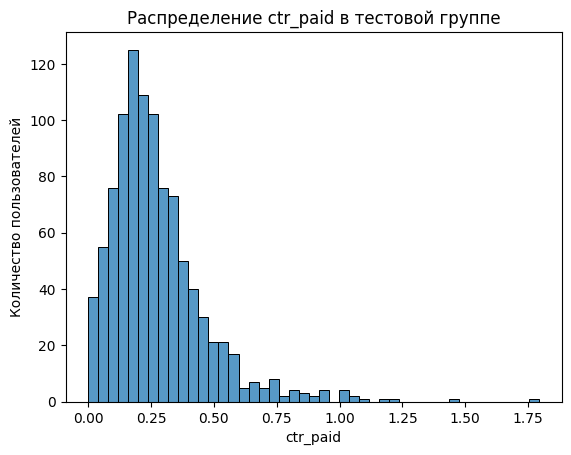

In [172]:
sns.histplot(df2[df2['group'] == 'test']['ctr_paid'])

plt.title('Распределение ctr_paid в тестовой группе')
plt.ylabel('Количество пользователей');

Гистограммы демонстрируют сильную правостороннюю асимметрию. Распределение не соответствует нормальному. Для сравнения групп используется **непараметрический U-тест Манна-Уитни**, который не требует нормальности распределения и устойчив к выбросам.

*Проверка значимости различия ctr_paid между группами*

In [173]:
mw_statistic, p_value = stats.mannwhitneyu(df2[df2['group'] == 'control']['ctr_paid'], df2[df2['group'] == 'test']['ctr_paid'], alternative='two-sided')

print(f"U-statistic: {mw_statistic}")
print('p-значение: ', p_value)

if p_value < alpha:
    print('Отвергаем нулевую гипотезу: разница статистически значима')
else:
    print(
        'Не получилось отвергнуть нулевую гипотезу, вывод о различии сделать нельзя')

U-statistic: 434670.0
p-значение:  8.239184674188939e-06
Отвергаем нулевую гипотезу: разница статистически значима


In [174]:
# Относительное изменение
mean_control = df2[df2['group'] == 'control']['ctr_paid'].mean()
mean_test = df2[df2['group'] == 'test']['ctr_paid'].mean()

lift = (mean_test - mean_control) / mean_control * 100
lift

np.float64(15.879920989677593)

In [175]:
ctr_paid_group = df2.groupby('group')['ctr_paid'].agg('mean').reset_index()
ctr_paid_group['ctr_paid_pct'] = ctr_paid_group['ctr_paid'] * 100
ctr_paid_group

,group,ctr_paid,ctr_paid_pct
0,control,0.236545,23.654506
1,test,0.274108,27.410823


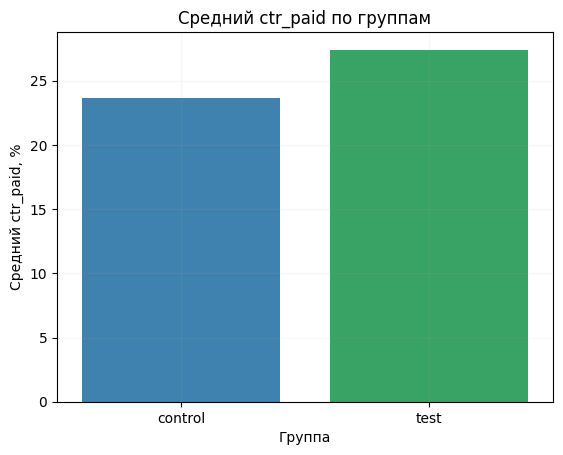

In [176]:
sns.barplot(ctr_paid_group, x='group', y='ctr_paid_pct', palette=['#2E86C1', '#28B463'], hue='group')

plt.grid(alpha=0.1)
plt.title('Средний ctr_paid по группам')
plt.xlabel('Группа')
plt.ylabel('Средний ctr_paid, %');

In [177]:
# Сравнение с MDE
if lift >= mde_2_weeks:
    print("Реальный эффект (15.8%) превышает запланированный MDE (6.4%). Это означает, что эксперимент не только статистически значим, но и превзошел бизнес-ожидания.")
else:
    print(f"Эффект есть, но меньше ожидаемого ({mde_2_weeks}%).")
    print("Возможно, стоит увеличить длительность теста или пересмотреть MDE.")

Реальный эффект (15.8%) превышает запланированный MDE (6.4%). Это означает, что эксперимент не только статистически значим, но и превзошел бизнес-ожидания.


*Рекомендации для бизнеса*

**Рекомендуется внедрить изменение** (размещение 4 платных элементов над 1 органическим) на всех пользователей, так как:
1. Различия статистически значимы.
2. Эффект превышает запланированный MDE.
3. Рост ctr_paid составил 15.8%, что положительно скажется на доходе.